In [31]:
from collections import defaultdict
from copy import deepcopy
from enum import Enum
import logging
import pandas as pd
import random

logging.basicConfig(level=logging.WARNING)


class Priority(Enum):
    A = 1
    B = 2
    C = 3
    D = 4
    E = 5


class Ship():
    def __init__(self, priority, attack, defense, hull):
        self.priority = priority
        self.attack = attack
        self.defense = defense
        self.hull = hull
        self.damage = 0

    def __str__(self):
        return (f"{type(self).__name__}: {str(self.priority)} {self.attack} "
                f"{self.defense} {self.hull} {self.damage}")


class Scout(Ship):
    def __init__(self):
        super().__init__(Priority.E, 3, 0, 1)


class Destroyer(Ship):
    def __init__(self):
        super().__init__(Priority.D, 4, 0, 1)


class Cruiser(Ship):
    def __init__(self):
        super().__init__(Priority.C, 4, 1, 2)


class Battlecruiser(Ship):
    def __init__(self):
        super().__init__(Priority.B, 5, 1, 2)


class Battleship(Ship):
    def __init__(self):
        super().__init__(Priority.A, 5, 2, 3)

In [42]:
def select_target(ship, targets):
    if not targets:
        return None

    # first target damaged ships
    damaged = next(filter(lambda x: x.damage > 0, targets), None)
    if damaged:
        return damaged

    # then whatever ship acts after you
    latership = next(filter(lambda x: x.priority.value > ship.priority.value, targets), None)
    if latership:
        return latership

    # wrap around to whatever ship acts before you next round
    return min(targets, key=lambda x: x.priority)


def rollshot(ship, target, bonus):
    logging.debug("ATTACKER: " + str(ship))
    logging.debug("TARGET: " + str(target))
    bonus_mod = 1 if bonus else 0
    roll = random.randint(1, 10)
    if roll == 1 or roll <= ship.attack + bonus_mod - target.defense:
        logging.debug(f"ROLL: {roll} HIT")
        return True

    logging.debug(f"ROLL: {roll} MISS")
    return False


def volley(shooters, targets, pri, bonus):
    cur_shooters = filter(lambda x: x.priority == pri, shooters)
    for ship in cur_shooters:
        target = select_target(ship, targets)
        if target is None:
            return

        if rollshot(ship, target, bonus):
            target.damage += 1
            if target.hull == target.damage:
                targets.remove(target)


def has_bonus(shooters, targets):
    return len(shooters) >= (len(targets)*2)


def battle(attacker, defender):
    rounds = 0
    while attacker and defender:
        rounds += 1
        def_bonus = has_bonus(defender, attacker)
        att_bonus = has_bonus(attacker, defender)
        for pri in Priority:
            if defender:
                volley(defender, attacker, pri, def_bonus)
            if attacker:
                volley(attacker, defender, pri, att_bonus)

    if attacker:
        return (len(attacker), rounds)
    return (-len(defender), rounds)


def simulate(attacker, defender, iterations):
    round_hist = defaultdict(int)
    result_hist = defaultdict(int)
    for i in range(iterations):
        cur_attacker = deepcopy(attacker)
        cur_defender = deepcopy(defender)

        results = battle(cur_attacker, cur_defender)
        round_hist[results[1]] += 1
        result_hist[results[0]] += 1
    return (result_hist, round_hist)

In [55]:
attacker = [Cruiser(), Cruiser()]
defender = [Battleship()]
results = simulate(attacker, defender, 10000)

In [56]:
attacker_wins = sum((x[1] for x in results[0].items() if x[0] < 0))
print(f"Defender won: {attacker_wins / 100}%")

Defender won: 39.35%


<Axes: title={'center': 'Remaining Ships'}>

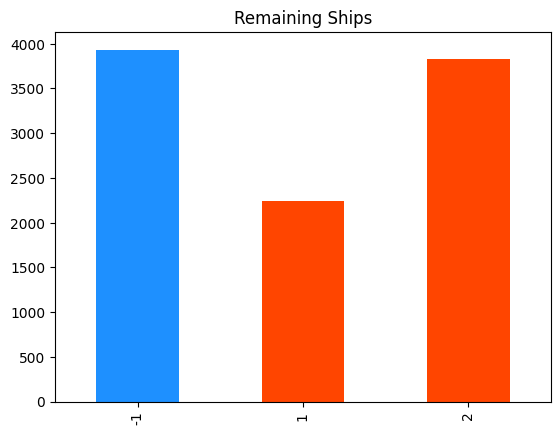

In [60]:
s = pd.Series(results[0]).sort_index()
s.plot.bar(title="Remaining Ships",
           color=['dodgerblue' if i < 0 else 'orangered' for i in s.index])

<Axes: title={'center': 'Round Count'}>

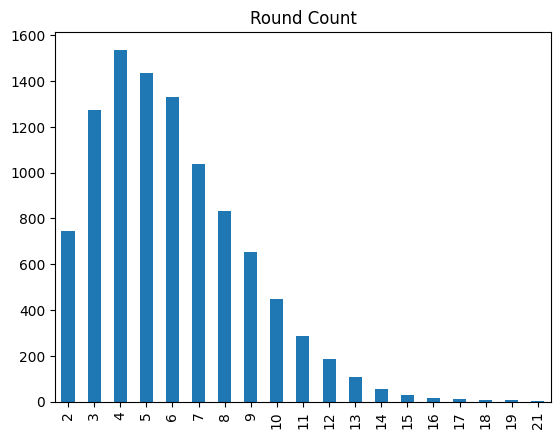

In [59]:
pd.Series(results[1]).sort_index().plot.bar(title="Round Count")